# Práctica 2. Funciones básicas de OpenCV. Tareas

Joel Morera Apaza

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Carga de la imagen, conversión a grises y contornos de Canny, que usan las tareas siguientes

In [2]:
#Lee la imagen del mandril, la convierte a grises y obtiene los contornos con Canny (se usan en las tareas)
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 200, 255)
print(img.shape, gris.shape)

(512, 512, 3) (512, 512)


TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Valor máximo por filas (maxfil): 0.322
Número de filas que cumplen la condición: 20
Posiciones (índices de fila): [  1   2   3   4   5   6   7   8  12  15  20  21  23  24  82  84  86  88
  94 100]


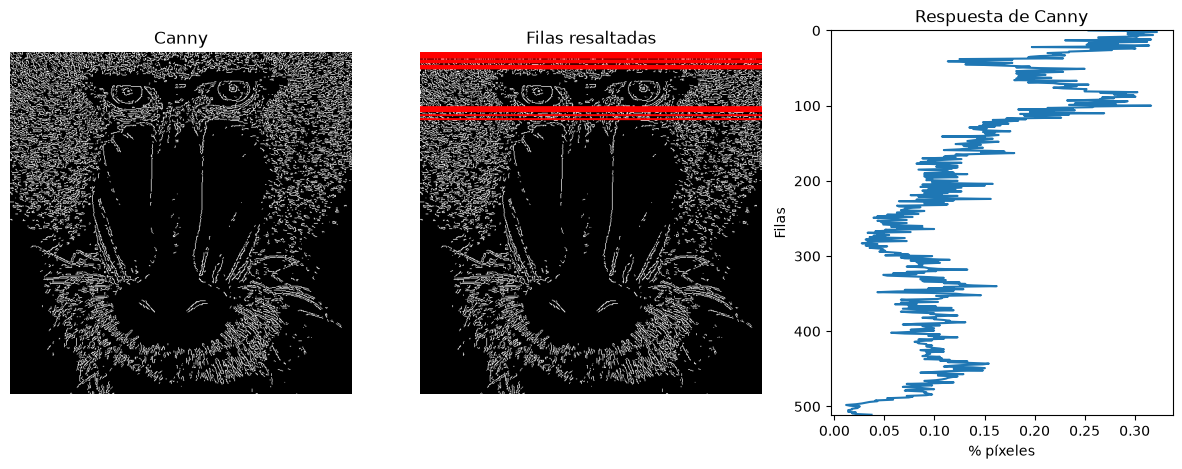

In [3]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
col_count = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por fila
filas = col_count[:, 0] / (255 * canny.shape[1])

maxfil = np.max(filas)
umbral = 0.90 * maxfil
filas_validas = np.where(filas >= umbral)[0]

print(f"Valor máximo por filas (maxfil): {maxfil:.3f}")
print(f"Número de filas que cumplen la condición: {len(filas_validas)}")
print(f"Posiciones (índices de fila): {filas_validas}")

canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)

for f in filas_validas:
    cv2.line(canny_color, (0, f), (canny.shape[1], f), (0, 0, 255), 2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Respuesta de Canny")
plt.xlabel("% píxeles")
plt.ylabel("Filas")
plt.plot(filas, range(len(filas)))
#Rango en y definido por las filas
plt.ylim([canny.shape[0], 0])

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title("Filas resaltadas")
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))
plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

Sobel: 11.9% de píxeles de borde
Valor máximo por columnas: 0.350, columnas que cumplen la condición: 1
Posiciones (índices de columna): [288]
Valor máximo por filas: 0.314, filas que cumplen la condición: 7
Posiciones (índices de fila): [ 3  4 20 51 81 82 83]

Canny: 12.7% de píxeles de borde
Valor máximo por columnas: 0.271, columnas que cumplen la condición: 3
Posiciones (índices de columna): [ 92 104 105]
Valor máximo por filas: 0.322, filas que cumplen la condición: 20
Posiciones (índices de fila): [  1   2   3   4   5   6   7   8  12  15  20  21  23  24  82  84  86  88
  94 100]


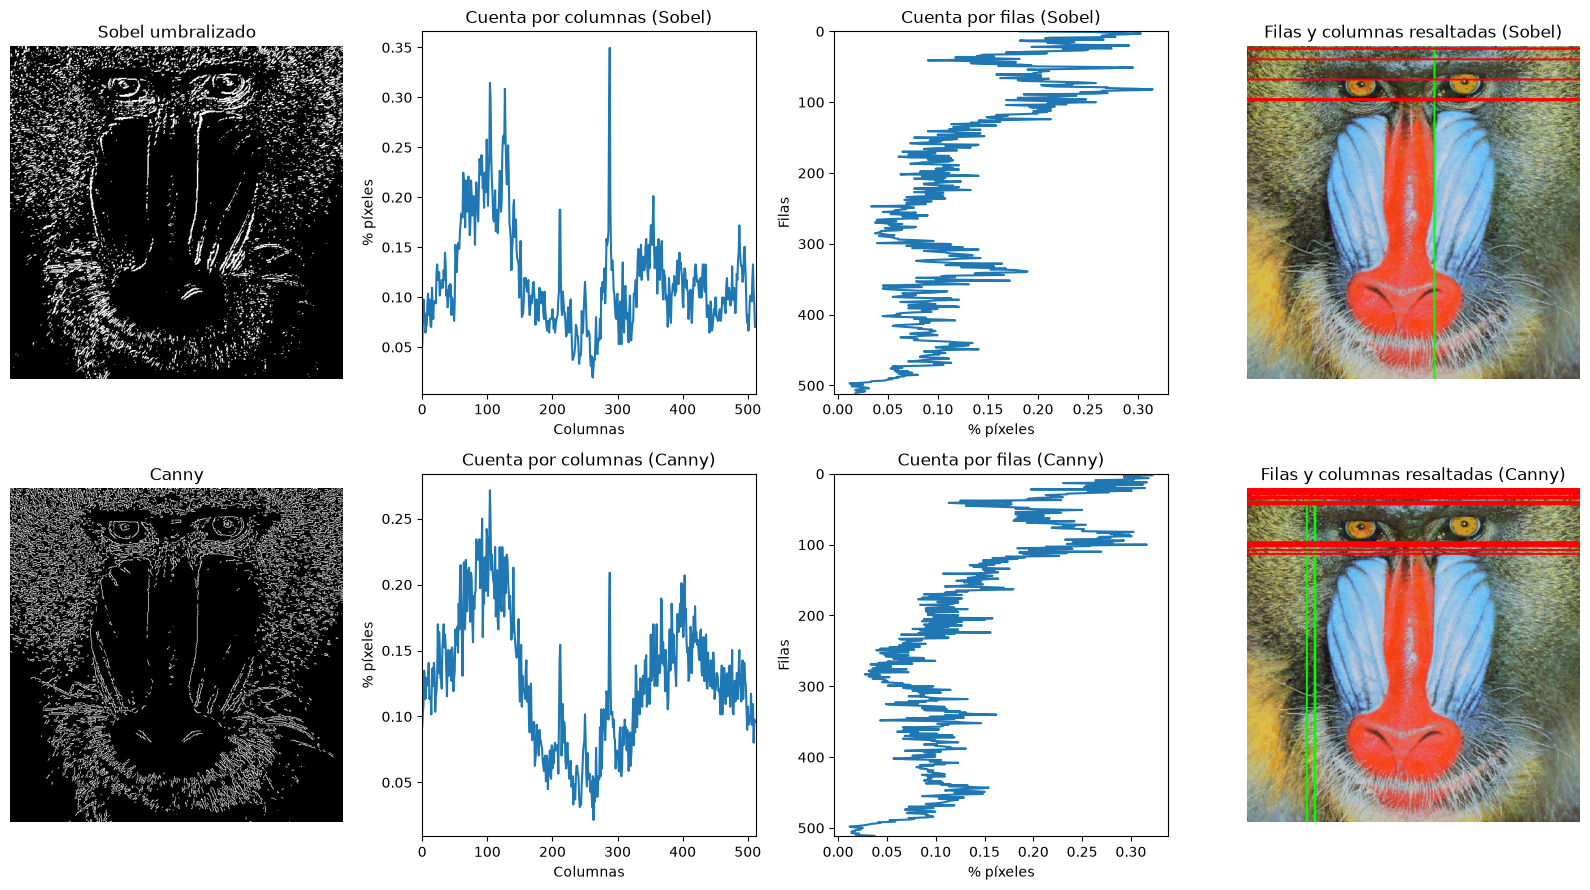

In [4]:
# Gaussiana para suavizar la imagen en grises, igual que en el ejemplo de Sobel
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical) y combina ambos resultados
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
sobel = cv2.add(sobelx, sobely)

#Convierte a 8 bits para poder umbralizar
sobel8 = cv2.convertScaleAbs(sobel)

#Umbralizado de la imagen de Sobel (0 o 255, igual que Canny)
#Con 130 queda un porcentaje de píxeles de borde parecido al de Canny, así se comparan en igualdad de condiciones
valorUmbral = 130
_, sobel_th = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

#Cuenta de píxeles blancos por columnas y por filas en Sobel umbralizado
col_counts_sobel = cv2.reduce(sobel_th, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_sobel = col_counts_sobel[0] / (255 * sobel_th.shape[0])
row_counts_sobel = cv2.reduce(sobel_th, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
filas_sobel = row_counts_sobel[:, 0] / (255 * sobel_th.shape[1])

#Misma cuenta en Canny para comparar
col_counts_canny = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_canny = col_counts_canny[0] / (255 * canny.shape[0])
row_counts_canny = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
filas_canny = row_counts_canny[:, 0] / (255 * canny.shape[1])

#Valores máximos y filas/columnas por encima del 0.90*máximo
maxcol_sobel = np.max(cols_sobel)
maxfil_sobel = np.max(filas_sobel)
cols_validas_sobel = np.where(cols_sobel >= 0.90 * maxcol_sobel)[0]
filas_validas_sobel = np.where(filas_sobel >= 0.90 * maxfil_sobel)[0]

maxcol_canny = np.max(cols_canny)
maxfil_canny = np.max(filas_canny)
cols_validas_canny = np.where(cols_canny >= 0.90 * maxcol_canny)[0]
filas_validas_canny = np.where(filas_canny >= 0.90 * maxfil_canny)[0]

#La media de la cuenta por columnas es la fracción de píxeles blancos de toda la imagen
print(f"Sobel: {100 * np.mean(cols_sobel):.1f}% de píxeles de borde")
print(f"Valor máximo por columnas: {maxcol_sobel:.3f}, columnas que cumplen la condición: {len(cols_validas_sobel)}")
print(f"Posiciones (índices de columna): {cols_validas_sobel}")
print(f"Valor máximo por filas: {maxfil_sobel:.3f}, filas que cumplen la condición: {len(filas_validas_sobel)}")
print(f"Posiciones (índices de fila): {filas_validas_sobel}")
print()
print(f"Canny: {100 * np.mean(cols_canny):.1f}% de píxeles de borde")
print(f"Valor máximo por columnas: {maxcol_canny:.3f}, columnas que cumplen la condición: {len(cols_validas_canny)}")
print(f"Posiciones (índices de columna): {cols_validas_canny}")
print(f"Valor máximo por filas: {maxfil_canny:.3f}, filas que cumplen la condición: {len(filas_validas_canny)}")
print(f"Posiciones (índices de fila): {filas_validas_canny}")

#Remarca las columnas (verde) y filas (rojo) seleccionadas sobre copias de la imagen del mandril
mandril_sobel = img.copy()
for c in cols_validas_sobel:
    cv2.line(mandril_sobel, (c, 0), (c, img.shape[0]), (0, 255, 0), 2)
for f in filas_validas_sobel:
    cv2.line(mandril_sobel, (0, f), (img.shape[1], f), (0, 0, 255), 2)

mandril_canny = img.copy()
for c in cols_validas_canny:
    cv2.line(mandril_canny, (c, 0), (c, img.shape[0]), (0, 255, 0), 2)
for f in filas_validas_canny:
    cv2.line(mandril_canny, (0, f), (img.shape[1], f), (0, 0, 255), 2)

#Visualiza: fila superior Sobel, fila inferior Canny
plt.figure(figsize=(16, 9))

plt.subplot(2, 4, 1)
plt.axis("off")
plt.title("Sobel umbralizado")
plt.imshow(sobel_th, cmap='gray')

plt.subplot(2, 4, 2)
plt.title("Cuenta por columnas (Sobel)")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols_sobel)
plt.xlim([0, sobel_th.shape[1]])

plt.subplot(2, 4, 3)
plt.title("Cuenta por filas (Sobel)")
plt.xlabel("% píxeles")
plt.ylabel("Filas")
plt.plot(filas_sobel, range(len(filas_sobel)))
plt.ylim([sobel_th.shape[0], 0])

plt.subplot(2, 4, 4)
plt.axis("off")
plt.title("Filas y columnas resaltadas (Sobel)")
plt.imshow(cv2.cvtColor(mandril_sobel, cv2.COLOR_BGR2RGB))

plt.subplot(2, 4, 5)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')

plt.subplot(2, 4, 6)
plt.title("Cuenta por columnas (Canny)")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols_canny)
plt.xlim([0, canny.shape[1]])

plt.subplot(2, 4, 7)
plt.title("Cuenta por filas (Canny)")
plt.xlabel("% píxeles")
plt.ylabel("Filas")
plt.plot(filas_canny, range(len(filas_canny)))
plt.ylim([canny.shape[0], 0])

plt.subplot(2, 4, 8)
plt.axis("off")
plt.title("Filas y columnas resaltadas (Canny)")
plt.imshow(cv2.cvtColor(mandril_canny, cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()

**¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?**

Para compararlos en igualdad de condiciones, Sobel se ha umbralizado a 130. Con ese umbral deja un 11,9 % de píxeles de borde, frente al 12,7 % de Canny.

- **Coinciden en lo global.** Los perfiles por filas tienen la misma forma: la mayor densidad de bordes está en la parte superior (pelo de la frente, filas 0–25) y en la zona de los ojos (filas ~80–100), y la mínima en el centro del hocico. Varias de las filas seleccionadas coinciden (3, 4, 20, 82–83).
- **En columnas difieren.** Sobel selecciona solo la columna 288, el contorno vertical muy contrastado entre el hocico rojo y la mejilla azul. Canny también tiene un pico ahí, pero no llega al 90 %, y selecciona las columnas 92, 104 y 105, junto al ojo izquierdo, donde hay mucha textura fina de pelo.
- **Sobel da bordes gruesos y depende mucho del umbral.** Es solo la derivada umbralizada, así que un borde fuerte produce varios píxeles contiguos (por eso selecciona filas consecutivas, 81–83). Con un umbral de 50, el 41 % de la imagen queda marcada como borde. Además, al combinar las dos derivadas con `cv2.add`, como en el ejemplo, se suman con signo. Donde la derivada en x y la derivada en y tienen signos opuestos se cancelan, y se pierden los bordes de una de las diagonales: se aprecia en la imagen, que parece iluminada desde una esquina.
- **Canny da bordes finos y continuos.** Aunque parte del gradiente de Sobel, adelgaza los bordes a 1 píxel y usa dos umbrales para conectar los tramos débiles con los fuertes. Por eso detecta bordes en todas las orientaciones, recoge mejor la textura del pelo y sus perfiles son más suaves, con las filas seleccionadas más repartidas (20 frente a 7).

En resumen: Sobel umbralizado resalta sobre todo los contornos de mayor contraste con trazos gruesos, y el resultado cambia mucho según el umbral. Canny ofrece contornos más finos y completos.

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

### Demostrador: *Virtual Air Guitar* reinterpretado

**Punto de partida.** En la instalación original el músico lleva guantes de color naranja; la cámara localiza ambas manos por su color, la distancia entre las manos elige la nota o acorde, y el gesto de la mano derecha dispara el rasgueo. El sonido se sintetiza en tiempo real.

**Reinterpretación.** Se mantiene la idea (tocar una guitarra que no existe) pero el procesamiento de la imagen se replantea usando únicamente las funciones vistas en las prácticas 1 y 2, y sin necesidad de guantes:

- **Guitarra virtual** dibujada sobre la imagen en espejo: un mástil con 6 trastes, cada uno asociado a un acorde (Em, G, C, D, Am, E), y el cuerpo de la guitarra, que es la zona de rasgueo.
- **Mano del mástil → acorde**, mediante **sustracción de fondo** (`createBackgroundSubtractorMOG2`). El fondo se aprende durante los primeros fotogramas y después se congela (`learningRate=0`) para que la mano, al quedarse quieta sobre un traste, no se incorpore al fondo. En la franja del mástil se cuenta el número de píxeles de primer plano por columna con `cv2.reduce`, igual que en la tarea de Canny. Como el brazo entra en el mástil desde el cuerpo, la mano es el extremo izquierdo de las columnas ocupadas (las que superan un porcentaje del máximo).
- **Modo guante** (un guiño a la instalación original): con la tecla `c` se calibra el color de un objeto o guante (mediana HSV de un recuadro) y la mano pasa a segmentarse con `cv2.inRange` en HSV, usando el centroide de la cuenta por columnas.
- **Mano de la púa → rasgueo**, mediante **diferencia entre fotogramas consecutivos** (`cv2.absdiff` + `cv2.threshold`) en la zona del cuerpo. Cuando la fracción de píxeles en movimiento supera un umbral, suena el acorde seleccionado. El sentido del rasgueo (hacia abajo o hacia arriba) se obtiene del desplazamiento vertical del centroide de la cuenta de píxeles por filas, y cada cambio de sentido cuenta como un nuevo rasgueo, así que se puede rasguear de forma continua.
- **Sonido sintetizado** con numpy, sin muestras grabadas ni paquetes adicionales: cada cuerda se modela con el algoritmo de cuerda pulsada de **Karplus-Strong**. Las cuerdas del acorde entran con unos milisegundos de retardo, en un orden o el contrario según el sentido del rasgueo. El timbre eléctrico se consigue con una saturación `tanh`. La reproducción usa `winsound`, incluido en Python para Windows; en otros sistemas el demostrador funciona sin sonido.
- **Salida visual**: las cuerdas vibran como una onda estacionaria que se amortigua tras cada rasgueo, hay un destello con el color del acorde y tres modos de visualización: *Normal*, *Neón* (contornos de Canny) y *Silueta* (primer plano de MOG2).

**Uso.** Al arrancar, mantén los brazos fuera de la franja del mástil mientras se aprende el fondo (unos 2 s). Después, coloca la mano izquierda sobre el mástil (a la izquierda de la imagen) para elegir el acorde y mueve la mano derecha arriba y abajo sobre el cuerpo de la guitarra para rasguear.

| Tecla | Acción |
|---|---|
| `ESC` | Salir |
| `m` | Cambiar modo visual (Normal / Neón / Silueta) |
| `e` | Alternar guitarra acústica / eléctrica |
| `b` | Volver a aprender el fondo |
| `c` | Calibrar el color del guante (3 s para colocarlo en el recuadro) |
| `x` | Dejar el color y volver a la sustracción de fondo |
| `d` | Depuración: perfil por columnas, nivel de movimiento y máscaras |

La primera celda sintetiza los sonidos y la segunda lanza el demostrador con la webcam.

Síntesis de los rasgueos con Karplus-Strong. Se precalcula un `.wav` por acorde, sentido del rasgueo y timbre

In [5]:
import os
import time
import wave
import tempfile

#winsound viene con Python en Windows y permite reproducir un .wav de forma asíncrona
try:
    import winsound
except ImportError:
    winsound = None

#Frecuencia de muestreo y duración de cada rasgueo
FS = 22050
DURACION = 2.0

#Acordes abiertos, notas MIDI de cada cuerda (de la 6ª, grave, a la 1ª, aguda)
#Orden en el mástil: del clavijero (izquierda de la imagen) hacia el cuerpo
ACORDES = {
    'Em': [40, 47, 52, 55, 59, 64],
    'G':  [43, 47, 50, 55, 59, 67],
    'C':  [48, 52, 55, 60, 64],
    'D':  [50, 57, 62, 66],
    'Am': [45, 52, 57, 60, 64],
    'E':  [40, 47, 52, 56, 59, 64],
}
NOMBRES = list(ACORDES)
#Color (BGR) asociado a cada acorde para la visualización
COLORES = [(255, 80, 200), (80, 220, 255), (80, 255, 120), (255, 200, 60), (60, 120, 255), (200, 255, 255)]


def midi_a_hz(nota):
    return 440.0 * 2 ** ((nota - 69) / 12)


def karplus_strong(f, n, rng, decaimiento=0.996):
    """Cuerda pulsada: ráfaga de ruido que recircula por una línea de retardo de periodo N con un filtro promediador"""
    N = int(round(FS / f))
    y = np.zeros(n + N + 1)
    ruido = rng.uniform(-1, 1, N + 1)
    #Suaviza la ráfaga inicial para un ataque menos metálico
    y[:N + 1] = np.convolve(ruido, [0.25, 0.5, 0.25], mode='same')
    #y[i] = decaimiento * (y[i-N] + y[i-N-1]) / 2, calculado por bloques de N muestras (cada bloque depende solo del anterior)
    for i in range(N + 1, len(y), N):
        fin = min(i + N, len(y))
        y[i:fin] = decaimiento * 0.5 * (y[i - N:fin - N] + y[i - N - 1:fin - N - 1])
    return y[:n]


def sintetiza_rasgueo(notas, hacia_abajo=True, electrica=False, retardo=0.012, semilla=0):
    """Suma las cuerdas del acorde con un pequeño retardo entre ellas, en un sentido u otro según el rasgueo"""
    rng = np.random.default_rng(semilla)
    n = int(FS * DURACION)
    señal = np.zeros(n)
    orden = notas if hacia_abajo else notas[::-1]
    for k, nota in enumerate(orden):
        ini = int(k * retardo * FS)
        señal[ini:] += karplus_strong(midi_a_hz(nota), n - ini, rng)
    señal /= np.max(np.abs(señal))
    if electrica:
        #Saturación suave (tanh) para un sonido de guitarra eléctrica distorsionada
        señal = np.tanh(6 * señal) / np.tanh(6)
    #Fundido final para evitar un chasquido al acabar
    fundido = int(0.05 * FS)
    señal[-fundido:] *= np.linspace(1, 0, fundido)
    return np.int16(0.8 * señal * 32767)


def guarda_wav(ruta, muestras):
    with wave.open(ruta, 'wb') as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(FS)
        f.writeframes(muestras.tobytes())


#Precalcula un .wav por acorde, sentido del rasgueo y timbre
carpeta_wav = tempfile.mkdtemp(prefix='airguitar_')
SONIDOS = {}
for i, nombre in enumerate(NOMBRES):
    for abajo in (True, False):
        for electrica in (False, True):
            ruta = os.path.join(carpeta_wav, f"{nombre}_{'ab' if abajo else 'ar'}_{'el' if electrica else 'ac'}.wav")
            guarda_wav(ruta, sintetiza_rasgueo(ACORDES[nombre], abajo, electrica, semilla=i))
            SONIDOS[(nombre, abajo, electrica)] = ruta


def toca(nombre, hacia_abajo, electrica):
    if winsound is not None:
        #SND_ASYNC no bloquea el bucle de vídeo; un nuevo rasgueo corta el anterior, como al volver a tocar las cuerdas
        winsound.PlaySound(SONIDOS[(nombre, hacia_abajo, electrica)],
                           winsound.SND_FILENAME | winsound.SND_ASYNC | winsound.SND_NODEFAULT)


print(f"{len(SONIDOS)} sonidos generados en {carpeta_wav}")
if winsound is None:
    print("winsound no disponible (no es Windows): el demostrador funcionará sin sonido")

#Escucha de prueba del acorde de Mi menor
from IPython.display import Audio
Audio(SONIDOS[('Em', True, False)])

24 sonidos generados en C:\Users\joelm\AppData\Local\Temp\airguitar_ebm65uu3


Demostrador con la webcam

In [ ]:
#Teclas: ESC salir | m modo visual | e acústica/eléctrica | b reaprender fondo | c calibrar color | x quitar color | d depuración

FRAMES_FONDO = 60        #Fotogramas para aprender el fondo antes de congelarlo
UMBRAL_COLUMNA = 0.25    #Una columna del mástil pertenece al brazo si su ocupación supera esta fracción del máximo
OCUPACION_MIN = 0.12     #Ocupación mínima de la columna máxima para considerar que hay mano en el mástil
UMBRAL_RASGUEO = 0.03    #Fracción de píxeles en movimiento en la zona de púa para disparar un rasgueo
PAUSA_RASGUEO = 0.15     #Segundos mínimos entre dos rasgueos
MODOS = ['Normal', 'Neon (Canny)', 'Silueta (MOG2)']


def texto(img, s, pos, escala=0.6, color=(255, 255, 255), grosor=1):
    #Texto con contorno negro para que se lea sobre cualquier fondo
    cv2.putText(img, s, pos, cv2.FONT_HERSHEY_SIMPLEX, escala, (0, 0, 0), grosor + 3, cv2.LINE_AA)
    cv2.putText(img, s, pos, cv2.FONT_HERSHEY_SIMPLEX, escala, color, grosor, cv2.LINE_AA)


def mascara_color(hsv, centro, tol_h=10):
    #Umbralizado en HSV alrededor del color calibrado (el tono es circular: el rojo está en ambos extremos)
    h, s, v = [int(c) for c in centro]
    bajo_s, bajo_v = max(s - 70, 60), max(v - 70, 40)
    if h - tol_h < 0:
        rangos = [(0, h + tol_h), (180 + h - tol_h, 179)]
    elif h + tol_h > 179:
        rangos = [(h - tol_h, 179), (0, h + tol_h - 180)]
    else:
        rangos = [(h - tol_h, h + tol_h)]
    mascara = np.zeros(hsv.shape[:2], np.uint8)
    for a, b in rangos:
        mascara = cv2.bitwise_or(mascara, cv2.inRange(hsv, (a, bajo_s, bajo_v), (b, 255, 255)))
    return mascara


vid = cv2.VideoCapture(0)
ret, frame = vid.read()
if not ret:
    vid.release()
    raise RuntimeError("No se pudo leer de la webcam")
H, W = frame.shape[:2]

#Zonas de la guitarra virtual sobre la imagen en espejo: mástil a la izquierda, cuerpo (zona de púa) a la derecha
mx0, mx1, my0, my1 = int(0.02 * W), int(0.46 * W), int(0.52 * H), int(0.70 * H)
px0, px1, py0, py1 = int(0.58 * W), int(0.90 * W), int(0.38 * H), int(0.92 * H)
ancho_traste = (mx1 - mx0) / len(NOMBRES)
y_cuerdas = np.linspace(my0 + 0.15 * (my1 - my0), my1 - 0.15 * (my1 - my0), 6)
xs_cuerdas = np.arange(mx0, px1 - 15, 6)
u_cuerdas = (xs_cuerdas - mx0) / (xs_cuerdas[-1] - mx0)

eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

frames_fondo = 0
color_hsv = None
calibrando_hasta = None
modo, electrica, depura = 0, False, False
acorde, x_mano = 0, None
pua_prev, cy_prev = None, None
activo, abajo_ultimo, t_ultimo = False, True, -10.0

try:
    while(True):
        ret, frame = vid.read()
        if not ret:
            break
        t = time.time()
        #Efecto espejo para que el usuario se vea como en un espejo
        framem = cv2.flip(frame, 1)

        # 1. Sustracción de fondo: se aprende durante FRAMES_FONDO fotogramas y después se congela (learningRate=0)
        #    para que la mano quieta sobre un traste no acabe absorbida por el fondo
        aprendiendo = frames_fondo < FRAMES_FONDO
        objetos = eliminadorFondo.apply(framem, learningRate=-1 if aprendiendo else 0)
        frames_fondo += 1
        #Las sombras se marcan con 127, el umbral las descarta
        _, objetos = cv2.threshold(objetos, 200, 255, cv2.THRESH_BINARY)

        # 2. Mano del mástil -> acorde
        if color_hsv is not None:
            hsv = cv2.cvtColor(framem[my0:my1, mx0:mx1], cv2.COLOR_BGR2HSV)
            mascara = mascara_color(hsv, color_hsv)
        else:
            mascara = objetos[my0:my1, mx0:mx1]
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
        #Cuenta de píxeles blancos por columna, como en la tarea de Canny
        cols = cv2.reduce(mascara, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] / (255 * mascara.shape[0])

        mano = None
        if not aprendiendo and cols.max() >= OCUPACION_MIN:
            if color_hsv is not None:
                #Guante/objeto de color: centroide horizontal de la máscara
                mano = np.sum(cols * np.arange(len(cols))) / np.sum(cols)
            else:
                #Silueta: el brazo entra desde el cuerpo, la mano es el extremo izquierdo de las columnas ocupadas
                mano = np.where(cols >= UMBRAL_COLUMNA * cols.max())[0][0]
        if mano is not None:
            #Suavizado exponencial para evitar saltos entre trastes
            x_mano = mano if x_mano is None else 0.6 * x_mano + 0.4 * mano
            acorde = int(np.clip(x_mano // ancho_traste, 0, len(NOMBRES) - 1))
        else:
            x_mano = None

        # 3. Mano de la púa -> rasgueo, por diferencia entre fotogramas consecutivos en la zona del cuerpo
        gris_pua = cv2.GaussianBlur(cv2.cvtColor(framem[py0:py1, px0:px1], cv2.COLOR_BGR2GRAY), (7, 7), 0)
        movimiento = np.zeros_like(gris_pua)
        if pua_prev is not None:
            dif = cv2.absdiff(gris_pua, pua_prev)
            _, movimiento = cv2.threshold(dif, 25, 255, cv2.THRESH_BINARY)
        pua_prev = gris_pua
        frac = cv2.countNonZero(movimiento) / movimiento.size

        #Sentido del rasgueo: desplazamiento vertical del centroide de la cuenta de píxeles por filas
        filas = cv2.reduce(movimiento, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0]
        direccion = None
        if frac > UMBRAL_RASGUEO / 2 and filas.sum() > 0:
            cy = np.sum(filas * np.arange(len(filas))) / filas.sum()
            if cy_prev is not None and abs(cy - cy_prev) > 2:
                direccion = bool(cy > cy_prev)  #True: hacia abajo
            cy_prev = cy
        else:
            cy_prev = None

        if frac > UMBRAL_RASGUEO and not aprendiendo and t - t_ultimo > PAUSA_RASGUEO:
            #Nuevo rasgueo al empezar un movimiento o al invertir su sentido (rasgueo arriba-abajo continuo)
            if not activo or (direccion is not None and direccion != abajo_ultimo):
                abajo = direccion if direccion is not None else not abajo_ultimo
                toca(NOMBRES[acorde], abajo, electrica)
                t_ultimo, abajo_ultimo, activo = t, abajo, True
        if frac < UMBRAL_RASGUEO / 2:
            activo = False

        # 4. Visualización
        color = COLORES[acorde]
        #Destello que decae tras cada rasgueo
        brillo = np.exp(-(t - t_ultimo) / 0.25)
        color_vivo = tuple(int(c + (255 - c) * brillo) for c in color)

        if modo == 1:
            #Neón: contornos de Canny del músico sobre la imagen oscurecida, con el color del acorde
            bordes = cv2.Canny(cv2.GaussianBlur(cv2.cvtColor(framem, cv2.COLOR_BGR2GRAY), (5, 5), 0), 60, 140)
            bordes = cv2.dilate(bordes, None)
            salida = (framem * 0.2).astype(np.uint8)
            salida[bordes > 0] = color_vivo
        elif modo == 2:
            #Silueta: primer plano del modelo de fondo teñido con el color del acorde
            salida = framem // 4
            tinte = np.full_like(framem, color_vivo)
            salida[objetos > 0] = cv2.addWeighted(framem, 0.4, tinte, 0.6, 0)[objetos > 0]
        else:
            salida = framem.copy()

        #Guitarra semitransparente: mástil, traste activo y cuerpo
        capa = salida.copy()
        cv2.rectangle(capa, (mx0, my0), (mx1, my1), (30, 60, 110), -1)
        xa = int(mx0 + acorde * ancho_traste)
        cv2.rectangle(capa, (xa, my0), (int(xa + ancho_traste), my1), color, -1)
        centro = ((px0 + px1) // 2, (py0 + py1) // 2)
        cv2.ellipse(capa, centro, ((px1 - px0) // 2, (py1 - py0) // 2), 0, 0, 360, (40, 90, 160), -1)
        salida = cv2.addWeighted(capa, 0.45, salida, 0.55, 0)
        cv2.circle(salida, centro, (py1 - py0) // 6, (20, 20, 20), 3)
        for i, nombre in enumerate(NOMBRES):
            x = int(mx0 + i * ancho_traste)
            cv2.line(salida, (x, my0), (x, my1), (180, 180, 180), 2)
            texto(salida, nombre, (x + 6, my0 - 8), 0.6, COLORES[i] if i == acorde else (255, 255, 255))

        #Cuerdas: onda estacionaria sin(pi*u) cuya amplitud decae tras el rasgueo
        amplitud = 8 * np.exp(-(t - t_ultimo) / 0.5)
        for j, yc in enumerate(y_cuerdas):
            ys = yc + amplitud * np.sin(np.pi * u_cuerdas) * np.sin(2 * np.pi * (9 + 2 * j) * t)
            pts = np.stack([xs_cuerdas, ys], axis=1).astype(np.int32)
            color_cuerda = color_vivo if amplitud > 0.5 else (210, 210, 210)
            cv2.polylines(salida, [pts], False, color_cuerda, 3 if j < 2 else 2 if j < 4 else 1, cv2.LINE_AA)

        if x_mano is not None:
            cv2.circle(salida, (int(mx0 + x_mano), (my0 + my1) // 2), 14, color, 3)

        #Calibración de color: muestrea la mediana HSV del recuadro central del mástil tras una cuenta atrás
        if calibrando_hasta is not None:
            cx, cyc = (mx0 + mx1) // 2, (my0 + my1) // 2
            cv2.rectangle(salida, (cx - 15, cyc - 15), (cx + 15, cyc + 15), (0, 255, 255), 2)
            texto(salida, f"Pon el objeto de color en el recuadro: {calibrando_hasta - t:.1f}", (mx0, my0 - 40), 0.6, (0, 255, 255))
            if t >= calibrando_hasta:
                muestra = cv2.cvtColor(framem[cyc - 15:cyc + 15, cx - 15:cx + 15], cv2.COLOR_BGR2HSV)
                color_hsv = np.median(muestra.reshape(-1, 3), axis=0)
                calibrando_hasta = None

        if depura:
            #Perfil de ocupación por columnas dibujado sobre el mástil y fracción de movimiento en la púa
            perfil = np.stack([mx0 + np.arange(len(cols)), my1 - cols * (my1 - my0)], axis=1).astype(np.int32)
            cv2.polylines(salida, [perfil], False, (0, 255, 255), 1)
            cv2.rectangle(salida, (px0, py0), (px1, py1), (0, 255, 255), 1)
            cv2.rectangle(salida, (px1 + 5, py1 - int(min(frac / (4 * UMBRAL_RASGUEO), 1) * (py1 - py0))), (px1 + 15, py1), (0, 255, 255), -1)
            yu = int(py1 - 0.25 * (py1 - py0))
            cv2.line(salida, (px1 + 2, yu), (px1 + 18, yu), (0, 0, 255), 2)
            cv2.imshow('Mascaras', np.hstack([cv2.resize(mascara, (320, 120)), cv2.resize(movimiento, (320, 120))]))

        texto(salida, NOMBRES[acorde], (W // 2 - 30, 60), 2.0, color_vivo, 3)
        texto(salida, f"Modo: {MODOS[modo]}", (10, 25))
        texto(salida, f"Timbre: {'electrica' if electrica else 'acustica'}", (10, 50))
        texto(salida, f"Mano: {'color' if color_hsv is not None else 'sustraccion de fondo'}", (10, 75))
        if aprendiendo:
            texto(salida, f"Aprendiendo fondo, aparta los brazos del mastil ({FRAMES_FONDO - frames_fondo})", (10, H // 3), 0.6, (0, 255, 255))
        texto(salida, "ESC salir | m modo | e timbre | b fondo | c color | x sin color | d depuracion", (10, H - 12), 0.45)

        cv2.imshow('Virtual Air Guitar', salida)

        tecla = cv2.waitKey(1) & 0xFF
        if tecla == 27:
            break
        elif tecla == ord('m'):
            modo = (modo + 1) % len(MODOS)
        elif tecla == ord('e'):
            electrica = not electrica
        elif tecla == ord('b'):
            eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
            frames_fondo = 0
        elif tecla == ord('c'):
            calibrando_hasta = t + 3
        elif tecla == ord('x'):
            color_hsv = None
        elif tecla == ord('d'):
            depura = not depura
            if not depura:
                cv2.destroyWindow('Mascaras')
finally:
    # Libera el objeto de captura, detiene el sonido y destruye ventanas
    vid.release()
    if winsound is not None:
        winsound.PlaySound(None, 0)
    cv2.destroyAllWindows()